In [1]:
import os
import sys
os.environ['PYTHONWARNINGS'] = 'ignore'
class NullWriter:
    def write(self, msg):
        pass
    def flush(self):
        pass
sys.stderr = NullWriter()

In [2]:
import scanpy as sc, matplotlib.pyplot as plt, pandas as pd, numpy as np, celldyc as cdc,scvelo as scv
import cellrank as cr
from cellrank import Lineage

In [3]:
_func = np.testing.assert_array_equal
np.testing.assert_array_equal = lambda x, y, **kwargs: _func(x, y, **kwargs)

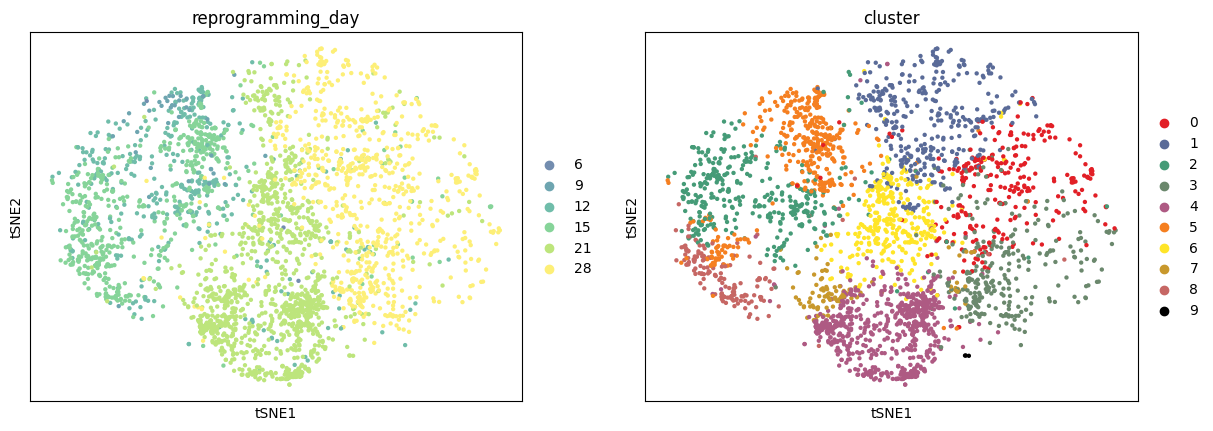

  0%|          | 0/3049 [00:00<?, ?cells/s]

computing velocity graph
finished.
computing velocity embedding
finished.


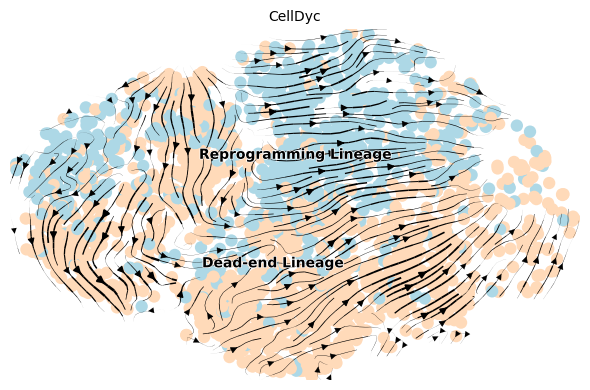

In [4]:
# Reproduce CellDyc’s analysis results on the reprogramming_lineage dataset.
adata= sc.read_h5ad("celldyc_reprogramming_lineage.h5ad")
sc.pl.embedding(
        adata,
        color=["reprogramming_day","cluster"],
        basis="tsne"
)
adata.obs['reprogramming'] = adata.obs['reprogramming'].replace({
            "True": 'Reprogramming Lineage',
            "False": 'Dead-end Lineage'
})
cdc.pl.plot_velocity_projection(adata,basis="tsne",color="reprogramming",figsize=(6,4),show=False,title="CellDyc",palette=[ '#FFDAB9','#ADD8E6'],alpha=1)
plt.tight_layout()
plt.show()


## We provide the complete code for running the CellDyc model below; however, due to variations in hardware configurations and runtime environments, the resulting outputs may exhibit minor discrepancies.
# adata=cdc.datasets.reprogramming_lineage()
# sc.pl.embedding(
#         adata,
#         color=["reprogramming_day","cluster"],
#         basis="tsne"
# )
# adata.obs['reprogramming'] = adata.obs['reprogramming'].replace({
#             "True": 'Reprogramming Lineage',
#             "False": 'Dead-end Lineage'
# })
# scv.pp.filter_and_normalize(adata, min_shared_counts=20, log=True, n_top_genes=2000)
# sc.tl.pca(adata)
# sc.pp.neighbors(adata, n_pcs=30, n_neighbors=30)
# cdc.tl.recover_dyc(adata,time_key="reprogramming_day")
# cdc.pl.plot_velocity_projection(adata,basis="tsne",color="reprogramming",figsize=(6,4),show=False,title="CellDyc",palette=[ '#FFDAB9','#ADD8E6'],alpha=1)
# plt.tight_layout()
# plt.show()

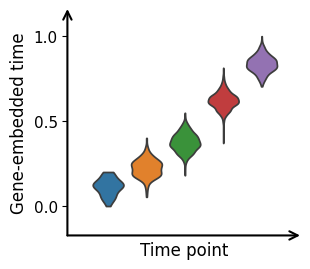

<Axes: xlabel='Time point', ylabel='Gene-embedded time'>

In [6]:
adata_=adata[adata.obs["reprogramming_day"]!='6']
cdc.pl.getime_violin(adata_,'getime','reprogramming_day')

  0%|          | 0/3049 [00:00<?, ?cell/s]

  0%|          | 0/3049 [00:00<?, ?cell/s]

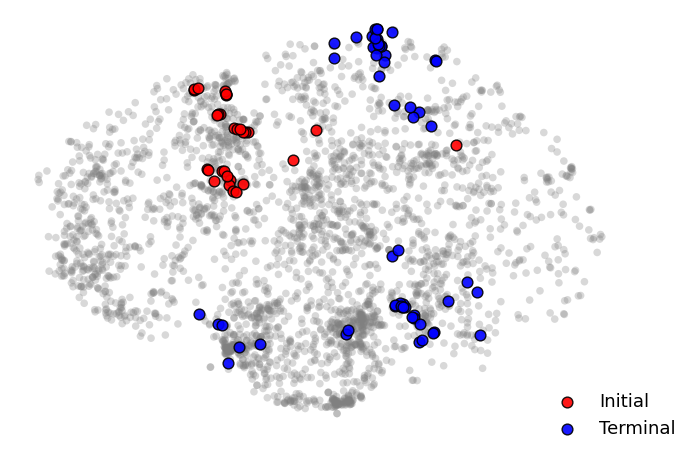

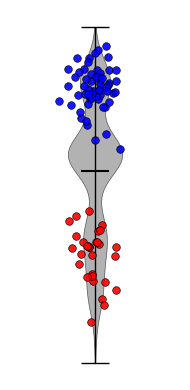

Defaulting to `'gmres'` solver.


  0%|          | 0/6 [00:00<?, ?/s]

[[0.05025802 0.0919128  0.06657724 0.01808408 0.63465037 0.1385172 ]
 [0.1064842  0.04788842 0.0425854  0.01506153 0.14158669 0.6463936 ]
 [0.05164062 0.09697697 0.06667716 0.01868012 0.61830853 0.14771642]
 ...
 [0.07366065 0.11979018 0.0784699  0.06306688 0.48907924 0.17593263]
 [0.0672088  0.12850707 0.08409218 0.04995976 0.53433371 0.13589812]
 [0.04262821 0.07436882 0.06279879 0.01091108 0.6939947  0.11529848]]
 names=[1_1, 1_2, 1_3, 1_4, 3_1, 3_2]


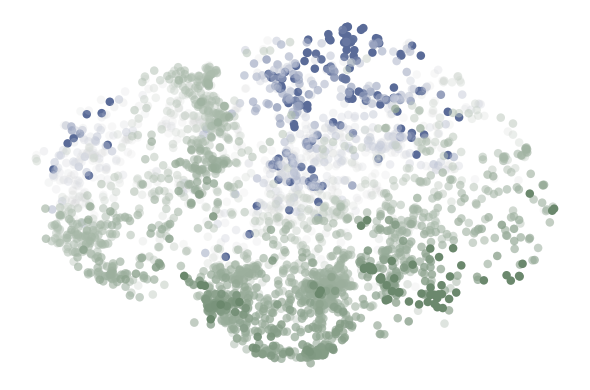

Reprogramming lineage data shape: (957, 2000)
Dead-end lineage data shape: (2092, 2000)


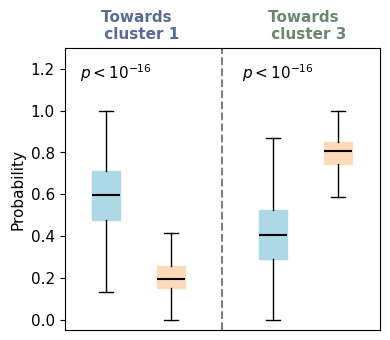

In [5]:
vk = cr.kernels.VelocityKernel(adata,xkey="X",vkey="velocity")
vk.compute_transition_matrix()
vk.write_to_adata()

g_fwd = cr.estimators.GPCCA(vk)
g_fwd.fit(cluster_key="cluster",n_states=15)
g_fwd.predict_terminal_states()
g_fwd.predict_initial_states()

cdc.rp.plot_submacrostates(adata, g_fwd)
cdc.rp.macrostates_violin(adata, g_fwd)

macrostates_sub = g_fwd.macrostates.cat.categories[g_fwd.macrostates.cat.categories.str.match(r'^[13]')].tolist()
g_fwd.set_terminal_states(states=macrostates_sub)
g_fwd.compute_fate_probabilities()
fate_probs = g_fwd.fate_probabilities
print(g_fwd.fate_probabilities)
state_to_idx = {name: idx for idx, name in enumerate(fate_probs.names)}
cats = macrostates_sub    
one_cats = [c for c in cats if c.startswith('1')]
three_cats = [c for c in cats if c.startswith('3')]
successful_state = fate_probs.X[:, [state_to_idx[c] for c in one_cats]].sum(axis=1)
dead_end_state   = fate_probs.X[:, [state_to_idx[c] for c in three_cats]].sum(axis=1)
fate_probs_merged = pd.DataFrame(
    {'successful_state': successful_state,
    'dead_end_state': dead_end_state},
    index=adata.obs_names
)
adata.obs['successful_state_prob'] = fate_probs_merged['successful_state']
adata.obs['dead_end_state_prob'] = fate_probs_merged['dead_end_state']
merged_probs = np.column_stack([
fate_probs_merged['successful_state'].values,
fate_probs_merged['dead_end_state'].values
])
merged_lineage = Lineage(
    merged_probs,
    names=['Reprogramming', 'Dead-end']
)
adata.obsm['merged_fate_probs'] = merged_lineage
cdc.rp.plot_fateprobabilities(adata,legend_loc="none")
cdc.rp.plot_lineage_fateprobabilities(adata)


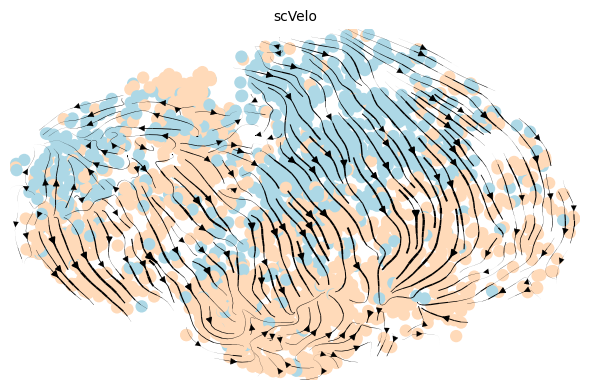

In [6]:
# Reproduce scVelo’s analysis results on the reprogramming_lineage dataset.
adata_scvelo = sc.read_h5ad('scvelo_reprogramming_lineage.h5ad')
scv.pl.velocity_embedding_stream(adata_scvelo, basis='tsne', color='reprogramming', legend_loc='none', figsize=(6,4),show=False,title="scVelo",palette=[ '#FFDAB9','#ADD8E6'],alpha=1)
plt.tight_layout()
plt.show()


## We provide the complete code for running the scVelo model below; however, due to variations in hardware configurations and runtime environments, the resulting outputs may exhibit minor discrepancies.
# adata_scvelo=sc.read_h5ad('reprogramming_lineage.h5ad')
# adata_scvelo.obs['reprogramming'] = adata_scvelo.obs['reprogramming'].replace({
#             "True": 'Reprogramming Lineage',
#             "False": 'Dead-end Lineage'
# })
# scv.pp.filter_and_normalize(adata_scvelo, min_shared_counts=20, log=True, n_top_genes=2000)
# sc.tl.pca(adata_scvelo)
# sc.pp.neighbors(adata_scvelo, n_pcs=30, n_neighbors=30)
# scv.pp.moments(adata_scvelo, n_pcs=None, n_neighbors=None)
# scv.tl.recover_dynamics(adata_scvelo)
# scv.tl.velocity(adata_scvelo, mode='dynamical', n_jobs=16)
# scv.tl.velocity_graph(adata_scvelo, n_jobs=16)
# scv.pl.velocity_embedding_stream(adata_scvelo, basis='tsne', color='reprogramming', legend_loc='none', figsize=(6,4),show=False,title="scVelo",palette=[ '#FFDAB9','#ADD8E6'],alpha=1)
# plt.tight_layout()
# plt.show()

  0%|          | 0/3049 [00:00<?, ?cell/s]

  0%|          | 0/3049 [00:00<?, ?cell/s]

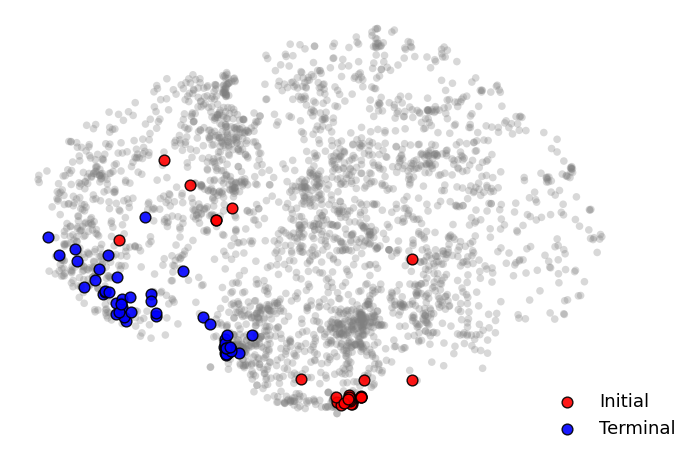

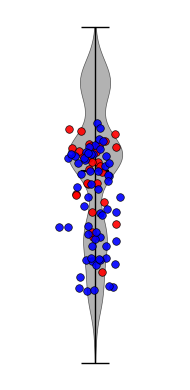

  0%|          | 0/6 [00:00<?, ?/s]

[[0.01590837 0.01288791 0.12104378 0.81945292 0.02782042 0.00261591]
 [0.00329652 0.00369946 0.07786042 0.89743944 0.01553038 0.0020065 ]
 [0.01815958 0.01450924 0.11964783 0.81656549 0.02822016 0.00263103]
 ...
 [0.06535001 0.08730927 0.10764918 0.69297972 0.04336397 0.003144  ]
 [0.0638078  0.07418294 0.11252825 0.70259361 0.04347659 0.0031945 ]
 [0.00151648 0.00192955 0.12739535 0.84121827 0.02503599 0.00261366]]
 names=[1_1, 1_2, 1_3, 3, 1_4, 1_5]


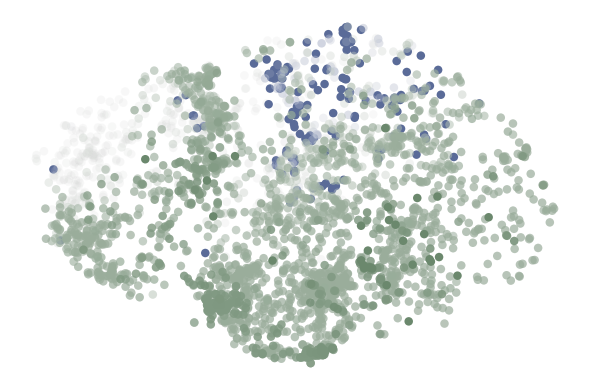

Reprogramming lineage data shape: (957, 2000)
Dead-end lineage data shape: (2092, 2000)


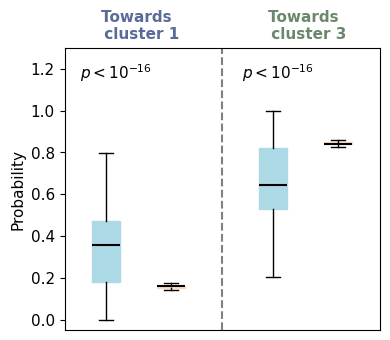

In [7]:
vk = cr.kernels.VelocityKernel(adata_scvelo)
vk.compute_transition_matrix()
vk.write_to_adata()
g_fwd = cr.estimators.GPCCA(vk)
g_fwd.fit(cluster_key="cluster",n_states=20)
g_fwd.predict_terminal_states()
g_fwd.predict_initial_states()
cdc.rp.plot_submacrostates(adata_scvelo, g_fwd)
adata_scvelo.obs['getime']=adata.obs['getime']
cdc.rp.macrostates_violin(adata_scvelo,g_fwd)
macrostates_sub = g_fwd.macrostates.cat.categories[g_fwd.macrostates.cat.categories.str.match(r'^[13]')].tolist()

g_fwd.set_terminal_states(states=macrostates_sub,allow_overlap=True)
g_fwd.compute_fate_probabilities(tol=1e-7)
fate_probs = g_fwd.fate_probabilities
print(fate_probs)
state_to_idx = {name: idx for idx, name in enumerate(fate_probs.names)}
cats = macrostates_sub    
one_cats = [c for c in cats if c.startswith('1')]
three_cats = [c for c in cats if c.startswith('3')]
successful_state = fate_probs.X[:, [state_to_idx[c] for c in one_cats]].sum(axis=1)
dead_end_state   = fate_probs.X[:, [state_to_idx[c] for c in three_cats]].sum(axis=1)
fate_probs_merged = pd.DataFrame(
    {'successful_state': successful_state,
    'dead_end_state': dead_end_state},
    index=adata_scvelo.obs_names
)
adata_scvelo.obs['successful_state_prob'] = fate_probs_merged['successful_state']
adata_scvelo.obs['dead_end_state_prob'] = fate_probs_merged['dead_end_state']
merged_probs = np.column_stack([
    fate_probs_merged['successful_state'].values,
    fate_probs_merged['dead_end_state'].values
])
merged_lineage = Lineage(
    merged_probs,
    names=['Reprogramming', 'Dead-end']
)
adata_scvelo.obsm['merged_fate_probs'] = merged_lineage
cdc.rp.plot_fateprobabilities(adata_scvelo,legend_loc="none")
cdc.rp.plot_lineage_fateprobabilities(adata_scvelo)

AnnData object with n_obs × n_vars = 3049 × 2000
    obs: 'timecourse', 'reprogramming_day', 'reprogramming', 'cell_type', 'cell_cycle', 'cluster', 'monocle_state', 'pseudotime', 'CellTagD0_85k', 'CellTagD3_85k', 'CellTagD13_85k', 'CellTagD0_48k', 'CellTagD3_48k', 'CellTagD13_48k', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'T_fwd_params', 'cell_cycle_colors', 'cluster_colors', 'log1p', 'neighbors', 'pca', 'reprogramming_colors', 'reprogramming_day_colors'
    obsm: 'X_diff', 'X_pca', 'X_tsne'
    varm: 'PCs'
    layers: 'spliced', 'unspliced'
    obsp: 'T_fwd', 'connectivities', 'distances'


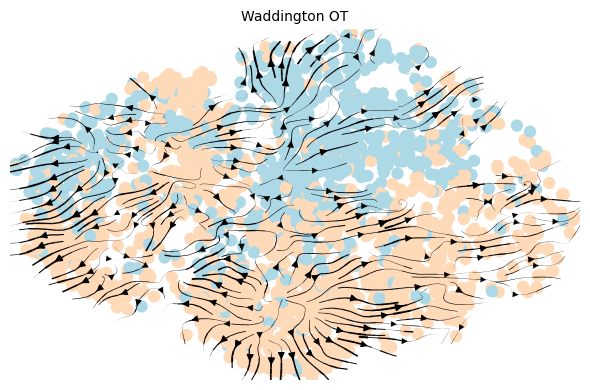

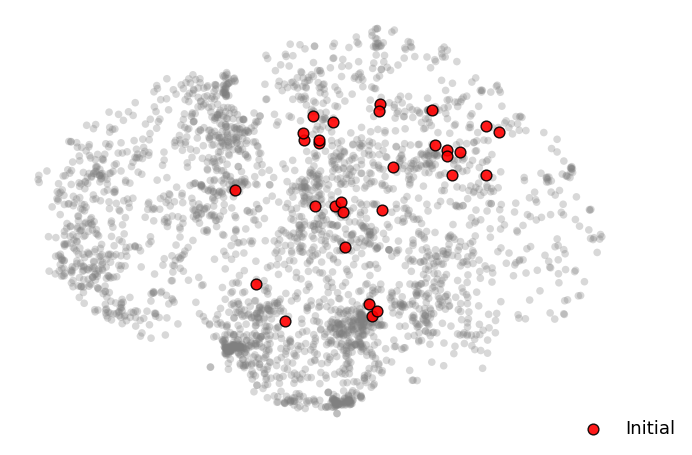

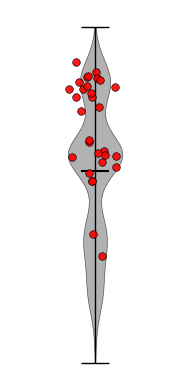

  0%|          | 0/6 [00:00<?, ?/s]

[[0.03638564 0.09427566 0.24952064 0.0937066  0.24580309 0.28030461]
 [0.13713429 0.17283317 0.09223915 0.13992207 0.15621623 0.30164627]
 [0.03206429 0.09506152 0.25467526 0.08465327 0.278203   0.25533931]
 ...
 [0.04935933 0.16152999 0.16129929 0.14394286 0.2283047  0.25556055]
 [0.07483509 0.2573605  0.09664495 0.19989078 0.15142615 0.21983971]
 [0.02664195 0.08361147 0.30077909 0.06614108 0.33805803 0.18476546]]
 names=[1_1, 1_2, 3_1, 1_3, 3_2, 1_4]


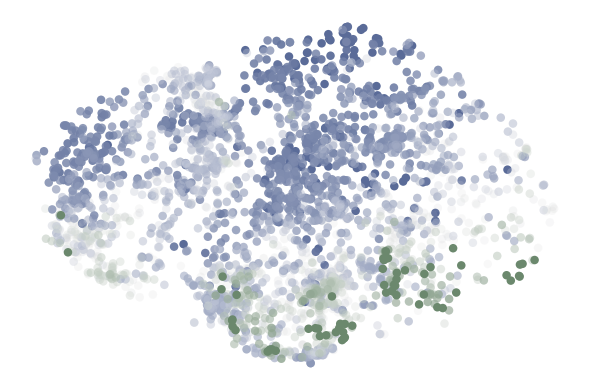

Reprogramming lineage data shape: (957, 2000)
Dead-end lineage data shape: (2092, 2000)


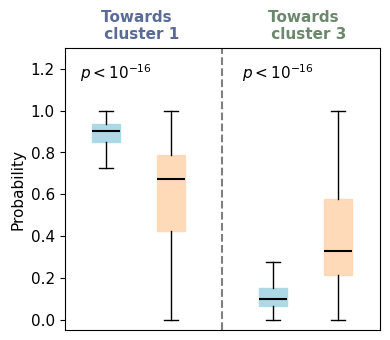

In [8]:
# Reproduce waddington-ot’s analysis results on the reprogramming_lineage dataset.
adata_wot = sc.read_h5ad('wot_reprogramming_lineage.h5ad')
print(adata_wot)
vk = cr.kernels.RealTimeKernel.from_adata(adata_wot,key="T_fwd")
vk.plot_projection(basis="tsne",connectivities=adata_wot.obsp["connectivities"],color="reprogramming",show=False, figsize=(6,4),palette=[ '#FFDAB9','#ADD8E6'],alpha=1,title='Waddington OT',legend_loc='none')

ax = plt.gca()
ax.grid(False)
plt.tight_layout()
plt.show()

## We provide the complete code for running the waddington-ot model below; however, due to variations in hardware configurations and runtime environments, the resulting outputs may exhibit minor discrepancies.
# import moscot as mt
# import wot
# adata_wot=sc.read_h5ad('reprogramming_lineage.h5ad')
# adata_wot.obs['reprogramming'] = adata_wot.obs['reprogramming'].replace({
#             "True": 'Reprogramming Lineage',
#             "False": 'Dead-end Lineage'
# })
# scv.pp.filter_and_normalize(adata_wot, min_shared_counts=20, log=True, n_top_genes=2000)
# sc.tl.pca(adata_wot)
# sc.pp.neighbors(adata_wot, n_pcs=30, n_neighbors=30)

# adata_wot.obs["reprogramming_day"] = adata_wot.obs["reprogramming_day"].astype(float).astype("category")
# ot_model = wot.ot.OTModel(adata_wot, day_field="reprogramming_day")
# ot_model.compute_all_transport_maps(tmap_out="reprogramming/")
# vk = cr.kernels.RealTimeKernel.from_wot(adata_wot, path="reprogramming/", time_key="reprogramming_day")
# vk.compute_transition_matrix()
# vk.write_to_adata()
# vk.plot_projection(basis="tsne",connectivities=adata_wot.obsp["connectivities"],color="reprogramming",show=False, figsize=(6,4),palette=[ '#FFDAB9','#ADD8E6'],alpha=1,title='Waddington OT',legend_loc='none')
# ax = plt.gca()
# ax.grid(False)
# plt.tight_layout()
# plt.show()



g_fwd = cr.estimators.GPCCA(vk)
g_fwd.fit(cluster_key="cluster",n_states=15)

# g_fwd.predict_terminal_states()
g_fwd.predict_initial_states()

cdc.rp.plot_submacrostates(adata_wot, g_fwd, show_initial=True, show_terminal=False)
adata_wot.obs['getime']=adata.obs['getime']
cdc.rp.macrostates_violin(adata_wot, g_fwd, show_initial=True, show_terminal=False)
macrostates_sub = g_fwd.macrostates.cat.categories[g_fwd.macrostates.cat.categories.str.match(r'^[13]')].tolist()
g_fwd.set_terminal_states(states=macrostates_sub,allow_overlap=True)
g_fwd.compute_fate_probabilities()
fate_probs = g_fwd.fate_probabilities
print(g_fwd.fate_probabilities)
state_to_idx = {name: idx for idx, name in enumerate(fate_probs.names)}
cats = macrostates_sub    
one_cats = [c for c in cats if c.startswith('1')]
three_cats = [c for c in cats if c.startswith('3')]
successful_state = fate_probs.X[:, [state_to_idx[c] for c in one_cats]].sum(axis=1)
dead_end_state   = fate_probs.X[:, [state_to_idx[c] for c in three_cats]].sum(axis=1)
fate_probs_merged = pd.DataFrame(
    {'successful_state': successful_state,
    'dead_end_state': dead_end_state},
    index=adata_wot.obs_names
)
adata_wot.obs['successful_state_prob'] = fate_probs_merged['successful_state']
adata_wot.obs['dead_end_state_prob'] = fate_probs_merged['dead_end_state']
merged_probs = np.column_stack([
    fate_probs_merged['successful_state'].values,
    fate_probs_merged['dead_end_state'].values
])
merged_lineage = Lineage(
    merged_probs,
    names=['Reprogramming', 'Dead-end']
)
adata_wot.obsm['merged_fate_probs'] = merged_lineage
cdc.rp.plot_fateprobabilities(adata_wot,legend_loc="none")
cdc.rp.plot_lineage_fateprobabilities(adata_wot)

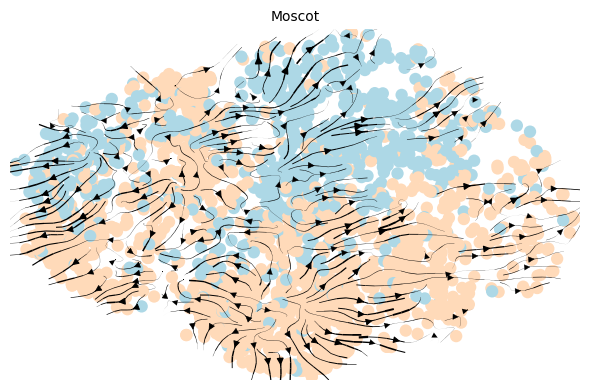

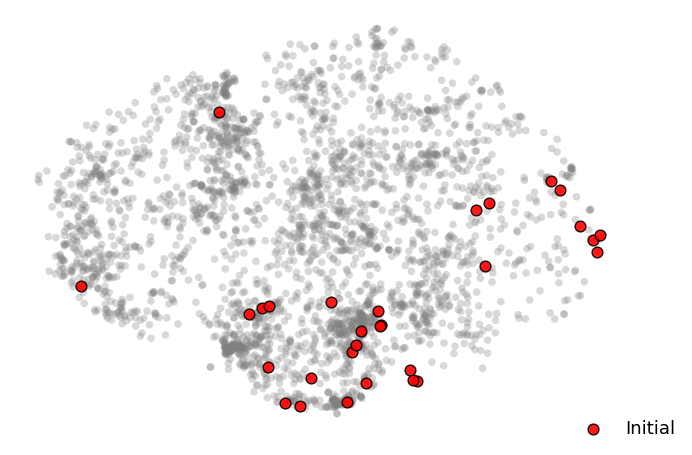

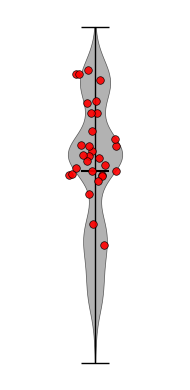

(<Figure size 200x400 with 1 Axes>, <Axes: >)

In [9]:
# Reproduce Moscot’s analysis results on the reprogramming_lineage dataset.
adata_moscot = sc.read_h5ad('moscot_reprogramming_lineage.h5ad')
vk = cr.kernels.RealTimeKernel.from_adata(adata_moscot,key="T_fwd")
vk.plot_projection(basis="tsne",connectivities=adata_moscot.obsp["connectivities"],color="reprogramming",show=False, figsize=(6,4),palette=[ '#FFDAB9','#ADD8E6'],alpha=1,title='Moscot',legend_loc='none')
ax = plt.gca()
ax.grid(False)
plt.tight_layout()
plt.show()

## We provide the complete code for running the Moscot model below; however, due to variations in hardware configurations and runtime environments, the resulting outputs may exhibit minor discrepancies.
# import moscot as mt
# import wot
# adata_moscot=sc.read_h5ad('reprogramming_lineage.h5ad')
# adata_moscot.obs['reprogramming'] = adata_moscot.obs['reprogramming'].replace({
#             "True": 'Reprogramming Lineage',
#             "False": 'Dead-end Lineage'
# })
# scv.pp.filter_and_normalize(adata_moscot, min_shared_counts=20, log=True, n_top_genes=2000)
# sc.tl.pca(adata_moscot)
# sc.pp.neighbors(adata_moscot, n_pcs=30, n_neighbors=30)
# adata_moscot.obs["reprogramming_day"] = adata_moscot.obs["reprogramming_day"].astype(float).astype("category")
# problem = mt.problems.TemporalProblem(adata_moscot)
# problem = problem.prepare(time_key="reprogramming_day").solve()
# vk = cr.kernels.RealTimeKernel.from_moscot(problem)
# vk.compute_transition_matrix()
# vk.write_to_adata()
# vk.plot_projection(basis="tsne",connectivities=adata_moscot.obsp["connectivities"],color="reprogramming",show=False, figsize=(6,4),palette=[ '#FFDAB9','#ADD8E6'],alpha=1,title='Moscot',legend_loc='none')
# ax = plt.gca()
# ax.grid(False)
# plt.tight_layout()
# plt.show()



g_fwd = cr.estimators.GPCCA(vk)
g_fwd.fit(cluster_key="cluster",n_states=15)

# g_fwd.predict_terminal_states()
g_fwd.predict_initial_states()

cdc.rp.plot_submacrostates(adata_moscot, g_fwd, show_initial=True, show_terminal=False)
adata_moscot.obs['getime']=adata.obs['getime']
cdc.rp.macrostates_violin(adata_moscot, g_fwd, show_initial=True, show_terminal=False)
